In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("marketing_campaign.csv", sep="\t")

print(df.shape)
df.head()

(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())
print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


In [4]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicates Before:", duplicates_before)
print("Duplicates After:", duplicates_after)

Duplicates Before: 0
Duplicates After: 0


In [5]:
text_cols = ["Education", "Marital_Status"]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [6]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)
print(df["Dt_Customer"].head())

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]


In [7]:
df.to_csv(
    "cleaned_marketing_campaign.csv",
    index=False
)

In [8]:
summary = df.describe(include="all")

summary.to_csv("summary_statistics.csv")

print(summary)

                  ID   Year_Birth   Education Marital_Status         Income  \
count    2240.000000  2240.000000        2240           2240    2240.000000   
unique           NaN          NaN           5              8            NaN   
top              NaN          NaN  Graduation        Married            NaN   
freq             NaN          NaN        1127            864            NaN   
mean     5592.159821  1968.805804         NaN            NaN   52237.975446   
min         0.000000  1893.000000         NaN            NaN    1730.000000   
25%      2828.250000  1959.000000         NaN            NaN   35538.750000   
50%      5458.500000  1970.000000         NaN            NaN   51381.500000   
75%      8427.750000  1977.000000         NaN            NaN   68289.750000   
max     11191.000000  1996.000000         NaN            NaN  666666.000000   
std      3246.662198    11.984069         NaN            NaN   25037.955891   

            Kidhome     Teenhome                 Dt

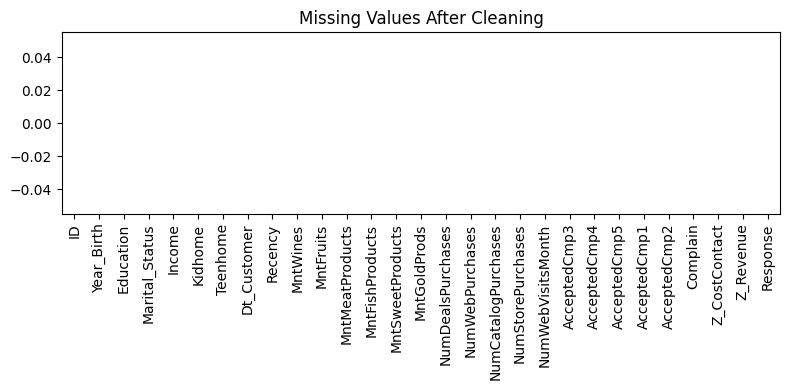

In [9]:
missing = df.isnull().sum()

plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values After Cleaning")
plt.tight_layout()
plt.savefig("missing_values.png")
plt.show()

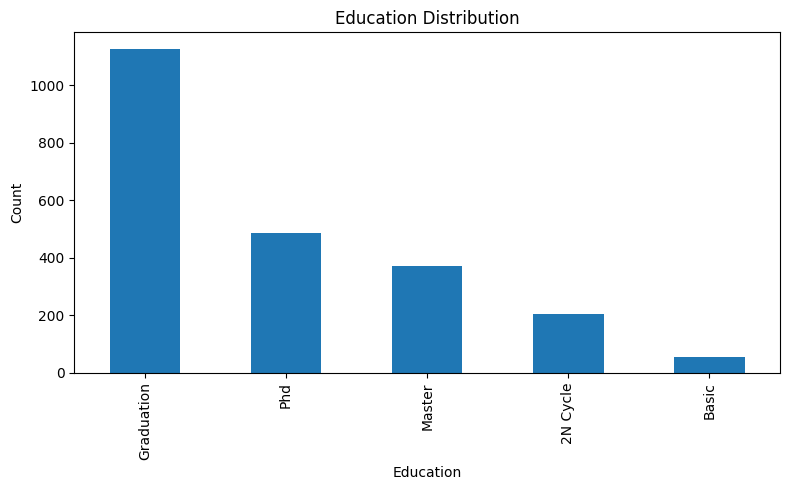

In [10]:
plt.figure(figsize=(8,5))

df["Education"].value_counts().plot(kind="bar")

plt.title("Education Distribution")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("education_distribution.png")

plt.show()

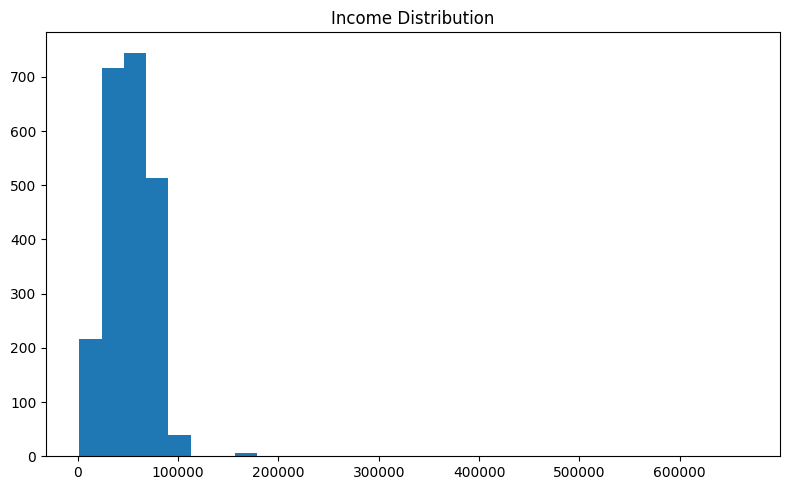

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["Income"], bins=30)

plt.title("Income Distribution")

plt.tight_layout()

plt.savefig("income_distribution.png")

plt.show()

In [12]:
report = {
    "Total Rows": len(df),
    "Total Columns": len(df.columns),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Average Income": round(df["Income"].mean(), 2)
}

print(report)

{'Total Rows': 2240, 'Total Columns': 29, 'Missing Values': np.int64(0), 'Duplicate Rows': np.int64(0), 'Average Income': np.float64(52237.98)}
